# Notebook 03: Collocation and Binning (All 6 Beams, IDW)

Collocates IS2 and CS2 observations using BallTree + IDW,
pooling all 6 IS2 beams. Validates on August 2022, then
batch-processes all months.

## 3.1 Setup

In [1]:
import sys, glob, time, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '/g/data/gv90/xl1657/phd/M2_workspace/notebooks')
from utils import read_atl10_v7, read_cs2_l2e, collocate_cs2_is2

# Paths
ATL10_DIR = '/g/data/gv90/xl1657/phd/M2_workspace/data/raw/ATL10'
CS2_DIR   = '/g/data/gv90/xl1657/phd/M2_workspace/data/raw/CS2_L2E'
OUT_DIR   = '/g/data/gv90/xl1657/phd/M2_workspace/output/collocated'
FIG_DIR   = '/g/data/gv90/xl1657/phd/M2_workspace/output/figures'

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print('Setup complete')


Setup complete


## 3.2 Single-Month Validation: August 2022

Test the full pipeline on one month before batch processing.

In [2]:
import glob

atl10_files = sorted(glob.glob(f'{ATL10_DIR}/**/*202208*.h5', recursive=True))
if not atl10_files:
    atl10_files = sorted(glob.glob(f'{ATL10_DIR}/*202208*.h5'))

cs2_files = sorted(glob.glob(f'{CS2_DIR}/**/*202208*.nc', recursive=True))
if not cs2_files:
    cs2_files = sorted(glob.glob(f'{CS2_DIR}/*202208*.nc'))

print(f'ATL10 files (Aug 2022): {len(atl10_files)}')
print(f'CS2 files (Aug 2022):   {len(cs2_files)}')

ATL10 files (Aug 2022): 346
CS2 files (Aug 2022):   3390


In [3]:
# ============================================================
# 3.2 Single-Month Validation: August 2022
# Process day-by-day to avoid memory issues
# ============================================================
import os
from datetime import datetime

# Group files by date
def extract_date_atl10(fname):
    """Extract YYYYMMDD from ATL10 filename."""
    base = os.path.basename(fname)
    for part in base.split('_'):
        if len(part) >= 8 and part[:8].isdigit():
            return part[:8]
    return None

def extract_date_cs2(fname):
    """Extract YYYYMMDD from CS2 filename like ...T004041..."""
    base = os.path.basename(fname)
    for part in base.split('_'):
        if 'T' in part and len(part) >= 15:
            return part[:8]
    return None

# Build date-indexed file lists
atl10_by_date = {}
for f in atl10_files:
    d = extract_date_atl10(f)
    if d:
        atl10_by_date.setdefault(d, []).append(f)

cs2_by_date = {}
for f in cs2_files:
    d = extract_date_cs2(f)
    if d:
        cs2_by_date.setdefault(d, []).append(f)

# Find dates with both IS2 and CS2 data
common_dates = sorted(set(atl10_by_date.keys()) & set(cs2_by_date.keys()))
print(f'ATL10 dates: {len(atl10_by_date)}')
print(f'CS2 dates:   {len(cs2_by_date)}')
print(f'Common dates: {len(common_dates)}')

ATL10 dates: 31
CS2 dates:   34
Common dates: 31


In [4]:
# ============================================================
# 3.3 Day-by-day collocation for August 2022
# ============================================================
from utils import collocate_cs2_is2

all_matched = []
total_is2 = 0
total_cs2 = 0

for date in common_dates:
    # Read only this day's files
    is2_frames = []
    for f in atl10_by_date[date]:
        df = read_atl10_v7(f)
        if len(df) > 0:
            is2_frames.append(df)
    
    cs2_frames = []
    for f in cs2_by_date[date]:
        df = read_cs2_l2e(f)
        if len(df) > 0:
            cs2_frames.append(df)
    
    if not is2_frames or not cs2_frames:
        continue
    
    df_is2 = pd.concat(is2_frames, ignore_index=True)
    df_cs2 = pd.concat(cs2_frames, ignore_index=True)
    total_is2 += len(df_is2)
    total_cs2 += len(df_cs2)
    
    # Collocate
    matched = collocate_cs2_is2(df_cs2, df_is2, R_m=5000, min_pts=10)
    
    if len(matched) > 0:
        matched['date'] = date
        all_matched.append(matched)
    
    print(f'{date}: IS2={len(df_is2):>7d}  CS2={len(df_cs2):>6d}  '
          f'matched={len(matched):>5d}')
    
    # Free memory
    del df_is2, df_cs2, is2_frames, cs2_frames, matched

# Combine results
if all_matched:
    df_matched_aug = pd.concat(all_matched, ignore_index=True)
    print(f'\n=== AUGUST 2022 SUMMARY ===')
    print(f'Total IS2 segments processed: {total_is2:,}')
    print(f'Total CS2 measurements processed: {total_cs2:,}')
    print(f'Total matched points: {len(df_matched_aug)}')
    print(f'IS2 freeboard median: {df_matched_aug.is2_fb_wm.median():.4f} m')
    print(f'CS2 radar freeboard median: {df_matched_aug.cs2_rfb.median():.4f} m')
    diff = df_matched_aug.is2_fb_wm - df_matched_aug.cs2_rfb
    print(f'Freeboard diff median (snow proxy): {diff.median():.4f} m')
else:
    print('\nNo matchups found for August 2022')

  Beam gt3l not found: 'Unable to synchronously open object (component not found)'
20220801: IS2=2954745  CS2= 18986  matched=    0
  Beam gt3l not found: 'Unable to synchronously open object (component not found)'
  Beam gt2l not found: 'Unable to synchronously open object (component not found)'
  Beam gt1l not found: 'Unable to synchronously open object (component not found)'
20220802: IS2=2631824  CS2= 19769  matched=    1
  Beam gt3l not found: 'Unable to synchronously open object (component not found)'
20220803: IS2=2853452  CS2= 19593  matched=  275
  Beam gt3l not found: 'Unable to synchronously open object (component not found)'
  Beam gt1l not found: 'Unable to synchronously open object (component not found)'
20220804: IS2=4840953  CS2= 20407  matched= 1251
  Beam gt1l not found: 'Unable to synchronously open object (component not found)'
20220805: IS2=3937812  CS2= 19243  matched=   56
  Beam gt1l not found: 'Unable to synchronously open object (component not found)'
20220806

In [6]:
import os

OUT_DIR = '/g/data/gv90/xl1657/phd/M2_workspace/output/collocated'
os.makedirs(OUT_DIR, exist_ok=True)

df_matched_aug['year_month'] = '202208'
df_matched_aug.to_csv(f'{OUT_DIR}/collocated_202208.csv', index=False)
print(f'Saved {len(df_matched_aug)} matchups to {OUT_DIR}/collocated_202208.csv')

Saved 11822 matchups to /g/data/gv90/xl1657/phd/M2_workspace/output/collocated/collocated_202208.csv


## 3.3 Visualise Collocation Results

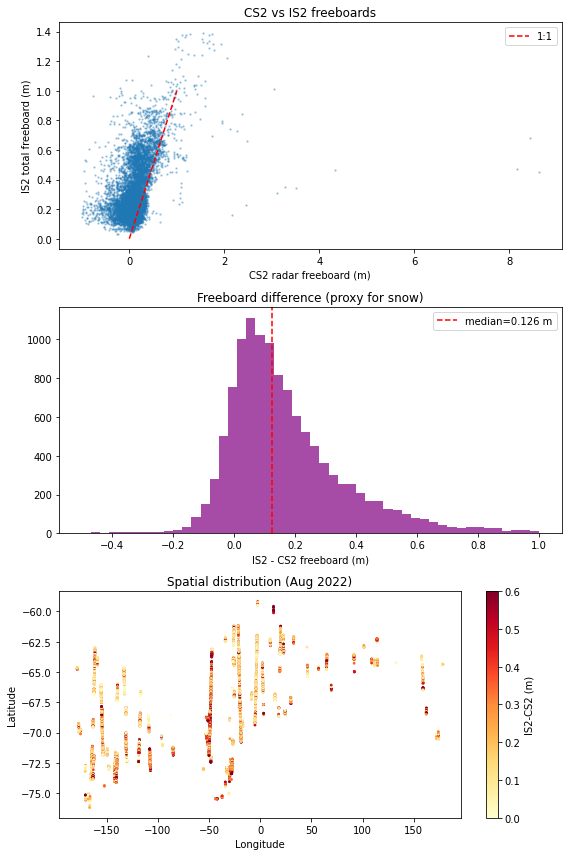

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# IS2 vs CS2 freeboards
ax = axes[0]
ax.scatter(df_matched_aug.cs2_rfb, df_matched_aug.is2_fb_wm, s=2, alpha=0.3)
ax.plot([0, 1], [0, 1], 'r--', label='1:1')
ax.set_xlabel('CS2 radar freeboard (m)')
ax.set_ylabel('IS2 total freeboard (m)')
ax.set_title('CS2 vs IS2 freeboards')
ax.legend()

# Freeboard difference histogram
ax = axes[1]
diff = df_matched_aug.is2_fb_wm - df_matched_aug.cs2_rfb
ax.hist(diff, bins=50, range=(-0.5, 1.0), color='purple', alpha=0.7)
ax.axvline(diff.median(), color='red', ls='--',
           label=f'median={diff.median():.3f} m')
ax.set_xlabel('IS2 - CS2 freeboard (m)')
ax.set_title('Freeboard difference (proxy for snow)')
ax.legend()

# Spatial distribution
ax = axes[2]
sc = ax.scatter(df_matched_aug.lon, df_matched_aug.lat, c=diff, s=3,
                cmap='YlOrRd', vmin=0, vmax=0.6)
plt.colorbar(sc, ax=ax, label='IS2-CS2 (m)')
ax.set_title('Spatial distribution (Aug 2022)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('/g/data/gv90/xl1657/phd/M2_workspace/output/figures/03_collocation_aug2022.png', dpi=300)
plt.show()